# Task for session2_cont and session3: 
## Edge-Preserving Denoising Filters & Feature Matching

**Instructions:**  
**please dont use .py to solve this task, just use tasks2.ipynb and edit the cells.**
- After forking the [SkyXperts-Vision-Course repo](https://github.com/ffathy-tdx/SkyXperts-Vision-Course) on GitHub. (you should have already dont this in the last session & uploaded task1)
- Go to your fork of the repo on GitHub.
- At the top, look for a yellow box that says “This branch is X commits behind…”
- Click the Sync fork or Update branch button.
The new task will show up in your tasks/ folder.  
- Upload your task to your forked repo (like you've done with task1 before)
---

## 1. DoG, LoG, and Edge-Preserving Denoising Filters

**Task:**
- Briefly read the descriptions below, then apply each filter to `'sample.jpg'` (or any test image you choose).
- Compare the results visually and write your observations.

**Background:**
- **DoG (Difference of Gaussian):** Used for edge detection by subtracting two blurred versions of the image (with different Gaussian sigmas).
- **LoG (Laplacian of Gaussian):** Uses a single Gaussian blur followed by Laplacian to highlight regions of rapid intensity change (edges).
- **Edge-Preserving Denoising (Bilateral Filter):** Smooths image while preserving edges (unlike simple Gaussian blur). You've already used this at the end of task1.

---

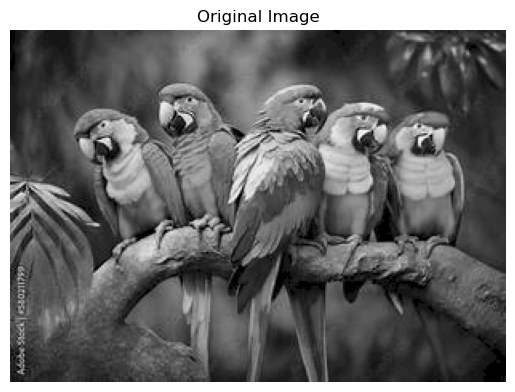

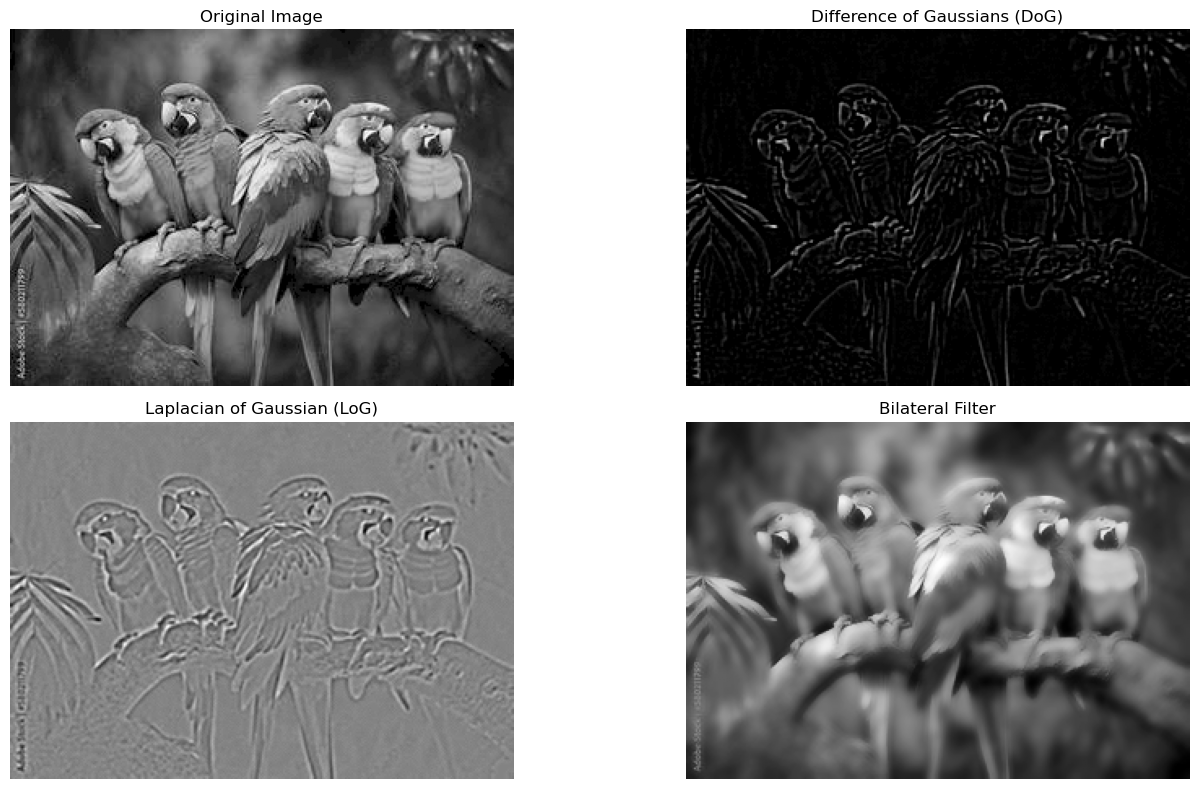

In [3]:
#Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Load image
img= cv2.imread('parrot.png', 0)  # Use grayscale for filtering
plt.imshow(img, cmap='gray'); plt.axis('off'); plt.title('Original Image'); plt.show()

#First step is to apply two Gaussian blurs with different sigma values because the (DoG) is computed by subtracting one blurred image from another.
blur1= cv2.GaussianBlur(img, (5, 5), 1)
blur2= cv2.GaussianBlur(img, (5, 5), 2)

dog= cv2.subtract(blur1, blur2) #Subtract the two blurred images to highlight edges/details


#First apply Gaussian blur to reduce noise 
gaussian= cv2.GaussianBlur(img, (5, 5), 1)
#Apply Laplacian to detect edges
log= cv2.Laplacian(gaussian, cv2.CV_64F)

#Bilateral filtering smooths the image while preserving edges
bilateral= cv2.bilateralFilter(img, 9, 75, 75)


plt.figure(figsize=(15, 8))
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(dog, cmap='gray')
plt.title('Difference of Gaussians (DoG)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(log, cmap='gray')
plt.title('Laplacian of Gaussian (LoG)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(bilateral, cmap='gray')
plt.title('Bilateral Filter')
plt.axis('off')

plt.tight_layout()
plt.show()

**Q1: What differences do you observe between DoG, LoG, and the edge-preserving filter?**

DoG and LoG both highlight the edges and details in the image, but they look a little different. DoG gives a smoother result and shows the main edges, while LoG makes the edges more noticeable and sharper. The bilateral filter is different because it smooths the image and removes some noise while keeping the important edges. So, DoG and LoG are mainly useful for detecting edges, while the bilateral filter is better for smoothing without losing too much detail.

## 2. Keypoints & Descriptors: SIFT vs. ORB

**Task:**
- Detect and plot keypoints on `'sample.jpg'` using SIFT and ORB.
- Compare the number and distribution of detected keypoints.

**Background:**
- **Keypoints:** Distinctive image points (corners/blobs) useful for matching.
- **Descriptors:** Vectors that describe local patches around keypoints for comparison/matching.

---

Number of SIFT keypoints: 499
Number of ORB keypoints: 451


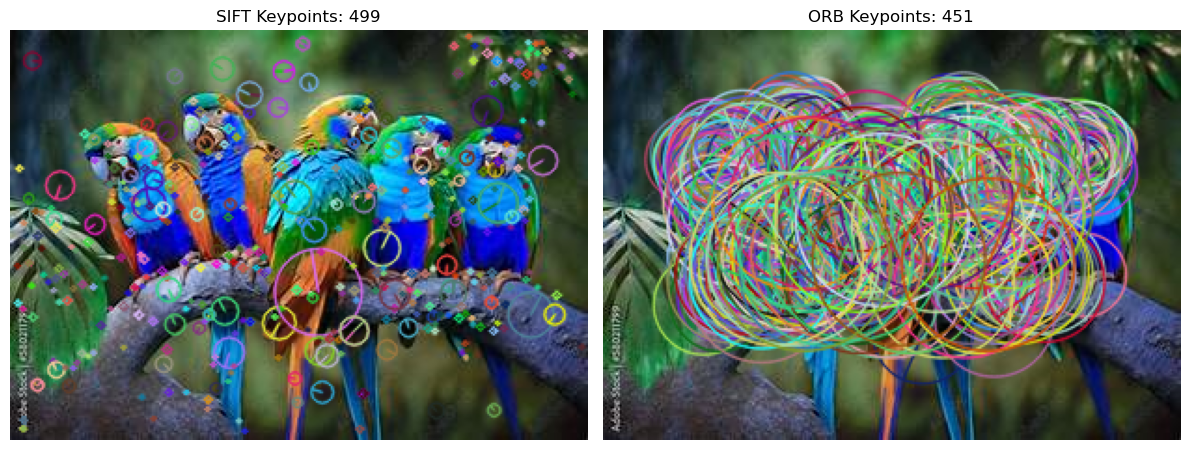

In [5]:
img= cv2.imread('parrot.png')

#Convert to grayscale because SIFT and ORB work with image intensity
gray= cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

#Detect keypoints and calculate their descriptors
sift_keypoints, sift_descriptors = sift.detectAndCompute(gray, None)

#Draw SIFT keypoints on the image because they are rich keypoints with size and orientation information
sift_img= cv2.drawKeypoints(img,sift_keypoints,None,flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)


#Create ORB detector
orb= cv2.ORB_create()

#Detect keypoints and calculate their descriptors
orb_keypoints, orb_descriptors = orb.detectAndCompute(gray, None)

#Draw ORB keypoints on the image for the same reason as SIFT keypoints
orb_img= cv2.drawKeypoints(img,orb_keypoints,None,flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

#We need to count the number of detected keypoints because SIFT and ORB may detect different numbers of keypoints in the same image. 
#This count can give us an idea of how many features each algorithm found, which can be useful for comparing their performance.
sift_count= len(sift_keypoints)
orb_count= len(orb_keypoints)

print("Number of SIFT keypoints:", sift_count)
print("Number of ORB keypoints:", orb_count)


plt.figure(figsize=(12, 5))

# SIFT keypoints
plt.subplot(1, 2, 1)
plt.imshow(sift_img)
plt.title(f"SIFT Keypoints: {sift_count}")
plt.axis("off")

# ORB keypoints
plt.subplot(1, 2, 2)
plt.imshow(orb_img)
plt.title(f"ORB Keypoints: {orb_count}")
plt.axis("off")

plt.tight_layout()
plt.show()

**Q2: How do the number and distribution of keypoints differ between SIFT and ORB?**

SIFT found 499 distinctive points while ORB found 451, so SIFT detected 48 more keypoints.
- SIFT (499): found more interesting points in the image, such as corners, edges, and detailed areas.
- ORB (451): found slightly fewer interesting points.
- The difference is not very large, so both methods were able to detect many similar useful areas.
- The distribution tells us where those points are located. They are usually concentrated in areas with more texture, edges, or details, rather than in smooth/blank areas.

## 3. Feature Matching with Descriptors

**Task:**
- Load a second image (e.g., `'sample2.jpg'`).
- Detect keypoints/descriptors using SIFT or ORB in both images.
- Match the features between the images using BFMatcher or FLANN.
- Plot the top matches.

**Background:**
- **Feature matching** helps recognize objects/scenes or estimate image transformations.

---

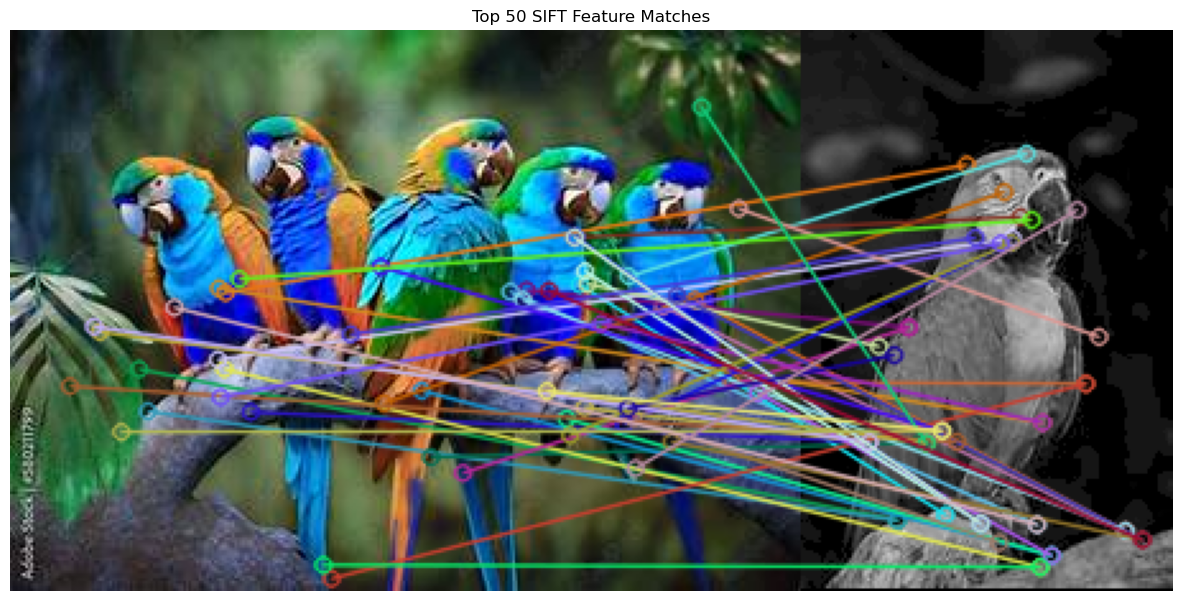

In [6]:
img2= cv2.imread('parrot2.png', 0)

sift = cv2.SIFT_create()

#We detect keypoints and descriptors in the first image because we need to match them with the keypoints and descriptors in the second image. The keypoints represent distinctive locations in the image, and the descriptors are feature vectors that describe the local appearance around each keypoint. By detecting these features in both images, we can then compare them to find correspondences between the two images, which is essential for tasks like image matching, object recognition, or 3D reconstruction.
keypoints1, descriptors1= sift.detectAndCompute(img, None)

keypoints2, descriptors2= sift.detectAndCompute(img2, None)

#Create BFMatcher
bf = cv2.BFMatcher() 
#The BFMatcher compares the descriptors from the first image with those from the second image and finds the best matches based on their similarity.
#This is an important step in feature matching, as it allows us to identify which keypoints in the first image correspond to keypoints in the second image, enabling tasks like object recognition.
matches= bf.match(descriptors1, descriptors2)

#Sort matches based on their distance
#Note: smaller distance means the features are more similar
matches= sorted(matches, key=lambda x: x.distance)

#Select the top 50 matches 
#50 is enough because it provides a good balance between showing enough matches to illustrate the feature correspondences and avoiding disturbance in the visualization.
#When i displayed too many matches the image became confusing and hard to understand
good_matches= matches[:50]

#Draw the matches
matched_img= cv2.drawMatches(img,keypoints1,img2,keypoints2,good_matches,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(15, 8))
plt.imshow(matched_img, cmap='gray')
plt.title("Top 50 SIFT Feature Matches")
plt.axis("off")
plt.show()

**Q3: What do you notice about the feature matches? Are there any mismatches or errors? How might you improve the matching process?**

There are not many feature matches across the two images as a whole. However, the algorithm was still able to find some similarities because the two parrots have similar colors and appearance, even though they are not the same parrot. Some of the matches may therefore be caused by similar visual features rather than identical points. The matching process could be improved by using a ratio test to remove weak matches and RANSAC to filter out incorrect matches (outliers)

**Bonus Task (Optional, for extra credit):**
- Try using different image preprocessing steps *before* edge detection or feature extraction.
    - For example:
        - Add noise to your image (e.g., Gaussian noise, salt-and-pepper noise).
        - Apply a sharpening filter to your image.
    - Then, run DoG, LoG, or any edge-preserving filter and observe the changes.
- **What to do:**
    - Show the results (images/plots) for at least one type of preprocessing + edge detection.
    - Briefly explain:
        - How does noise affect edge maps or keypoints?
        - Does sharpening make features easier or harder to detect/match?

**You can add your code and observations in the cells below.**


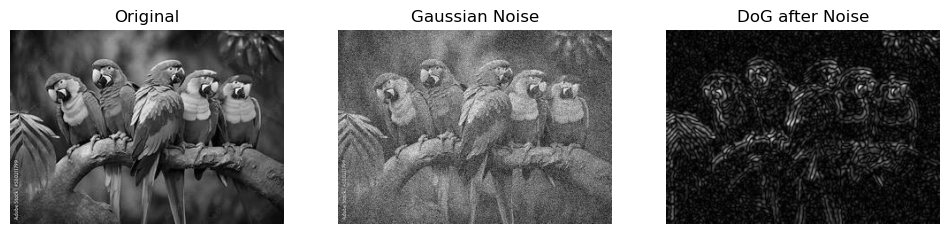

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#Convert image to grayscale because SIFT and ORB work with image intensity
gray= cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#add Gaussian noise to test 
noise= np.random.normal(0, 25, gray.shape) #random is used to generate random numbers to distribute noise across the image
noisy= gray.astype(np.float32) + noise #add the noise to the grayscale image

#Apply Gaussian blur
blurred= cv.GaussianBlur(noisy, (5, 5), 1)

#Difference of Gaussians (DoG)
gaussian1= cv.GaussianBlur(blurred, (5, 5), 1)
gaussian2= cv.GaussianBlur(blurred, (9, 9), 2)

dog= cv.absdiff(gaussian1, gaussian2)

plt.figure(figsize=(12, 8))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(noisy, cmap='gray')
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(dog, cmap='gray')
plt.title("DoG after Noise")
plt.axis("off")

plt.show()

_What are your observations?_
-adding the gaussian noise made the image grainy and reduced its visual clarity
-after aapplying DoG, the main edges appeared more 
-the noise also produced unwanted extra edges making DoG result darker and noiser therefore DoG can improvr edges but noise can affect the quality of the detected features

## 4. Reflection (Optional)

- What was the most challenging or interesting part of this task for you?
- Any feedback or thoughts?

The most interesting part of this task was running the code and actually observing how the image changed after applying different filters and adding noise. I liked seeing the effects of each step rather than only learning about them theoretically. It was especially interesting to see how noise could affect the detected features and how filters could either improve the image or change its details. 